In [4]:
# ── Cell 1: Load checkpoint & compute metrics ──────────────────────────────────
import os, json, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

LABEL_NAMES = [
    "No Defense", "Action", "Major Image-Dist.", "Disavowal",
    "Minor Image-Dist.", "Neurotic", "Obsessional", "High-Adaptive", "Needs More Info",
]

# ── Load checkpoint ────────────────────────────────────────────────────────────
REMOTE_CKPT = "/kaggle/input/datasets/ahmedalfeysani/psydef-checkpoints/eval_train_checkpoint.json"
LOCAL_CKPT  = "/kaggle/working/eval_train_checkpoint.json"

ckpt_path = REMOTE_CKPT if os.path.exists(REMOTE_CKPT) else LOCAL_CKPT
with open(ckpt_path) as f:
    ckpt = json.load(f)

y_true = np.array(ckpt["y_true"])
y_pred = np.array(ckpt["y_pred"])

print(f"Loaded from : {ckpt_path}")
print(f"Samples     : {len(y_true)}")
print(f"Last index  : {ckpt['last_index']}")
print(f"Saved at    : {ckpt.get('saved_at', 'unknown')}")
print(f"Errors      : {len(ckpt.get('errors', []))}")

Loaded from : /kaggle/input/datasets/ahmedalfeysani/psydef-checkpoints/eval_train_checkpoint.json
Samples     : 1800
Last index  : 1799
Saved at    : 2026-03-30 04:30:47
Errors      : 0


In [5]:
# ── Cell 2: Metrics ────────────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred) * 100
p, r, f1, _ = precision_recall_fscore_support(
    y_true, y_pred,
    labels=list(range(1, 9)),
    average="macro",
    zero_division=0,
)

print("\n" + "="*60)
print("  ZERO-SHOT RESULTS — Qwen3-8B (thinking=True)")
print("  Paper reference: Qwen3-Next (w/)  →  Table 5")
print("="*60)
print(f"  Accuracy              : {acc:.2f}   (paper: 44.28)")
print(f"  Macro Precision (1-8) : {p*100:.2f}   (paper: 27.23)")
print(f"  Macro Recall    (1-8) : {r*100:.2f}   (paper: 21.58)")
print(f"  Macro F1        (1-8) : {f1*100:.2f}   (paper: 20.68)")
print("="*60)

print("\nPer-class Report:")
print(classification_report(
    y_true, y_pred,
    labels=list(range(9)),
    target_names=LABEL_NAMES,
    zero_division=0,
))


  ZERO-SHOT RESULTS — Qwen3-8B (thinking=True)
  Paper reference: Qwen3-Next (w/)  →  Table 5
  Accuracy              : 34.22   (paper: 44.28)
  Macro Precision (1-8) : 17.73   (paper: 27.23)
  Macro Recall    (1-8) : 16.70   (paper: 21.58)
  Macro F1        (1-8) : 15.36   (paper: 20.68)

Per-class Report:
                   precision    recall  f1-score   support

       No Defense       0.38      0.74      0.50       286
           Action       0.09      0.06      0.07       102
Major Image-Dist.       0.12      0.13      0.12        60
        Disavowal       0.13      0.36      0.19        94
Minor Image-Dist.       0.10      0.19      0.13        81
         Neurotic       0.03      0.07      0.04        44
      Obsessional       0.19      0.12      0.15       167
    High-Adaptive       0.70      0.34      0.45       938
  Needs More Info       0.07      0.07      0.07        28

         accuracy                           0.34      1800
        macro avg       0.20      0.23 

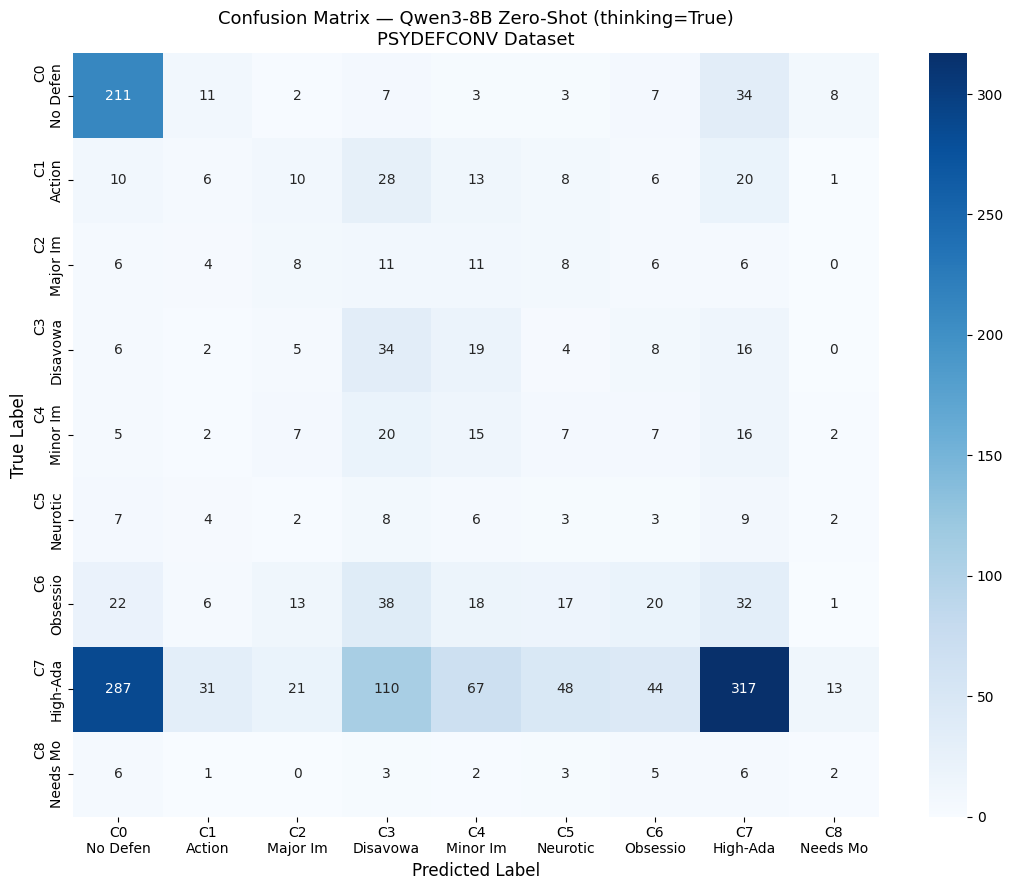

Saved → /kaggle/working/confusion_matrix_qwen3.png


In [6]:
# ── Cell 3: Confusion matrix ───────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=list(range(9)))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"C{i}\n{LABEL_NAMES[i][:8]}" for i in range(9)],
    yticklabels=[f"C{i}\n{LABEL_NAMES[i][:8]}" for i in range(9)],
    ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — Qwen3-8B Zero-Shot (thinking=True)\nPSYDEFCONV Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_qwen3.png", dpi=150)
plt.show()
print("Saved → /kaggle/working/confusion_matrix_qwen3.png")